## **Sales Performance Analysis of a Superstore Using Python**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Table of Contents

1. Business Understanding
2. Data Overview
3. Data Cleaning
4. Exploratory Data Analysis
5. Business Insights
6. Recommendations
7. Executive Summary

# Business Understanding

## Business Problem

The company aims to identify the key factors influencing sales performance and profitability across products, categories, and regions in order to improve decision-making and maximize business growth.

## Objectives

- Identify the best-performing product categories.
- Identify products generating losses.
- Analyze sales performance by region.
- Analyze yearly sales trends.
- Analyze the relationship between discount and profitability.

## Business Questions

1. Which category generates the highest profit?
2. Which products cause the greatest losses?
3. Which region contributes the highest sales?
4. Does discount affect profitability?
5. How do sales change over time?

# Data Overview

In [2]:
df.shape

(9994, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**Dataset Characteristics**

Transactions : 9,994

Features : 21

Missing Values : 0

Duplicates : 0

Period :
2014–2017

# Data Cleaning

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October


The following preprocessing steps were performed to ensure the dataset was ready for analysis:

- Checked for missing values (no missing values found).
- Checked for duplicate rows (no duplicates found).
- Converted the `Order Date` column to datetime format for time-based analysis.
- Created `Year` and `Month` columns to support trend analysis by time period.

# Exploratory Data Analysis

## Sales by Category

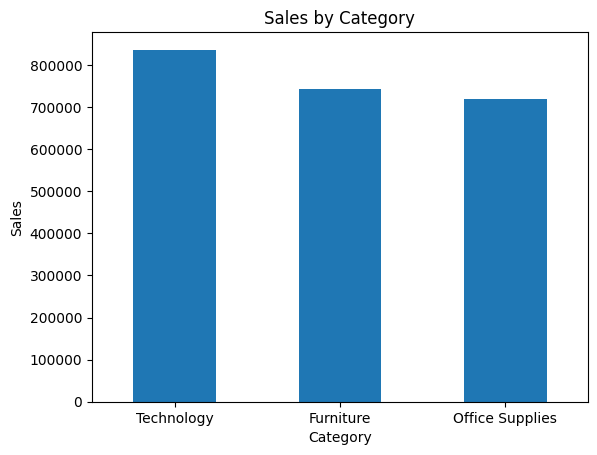

In [8]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

Observation:

The Technology category generated the highest volume of sales (surpassing 800,000), followed closely by Furniture in second place, and Office Supplies contributing the lowest sales among the three (hovering around 720,000). Although there is a clear ranking, the gap in sales volume between all three categories is relatively narrow.

Insight:

While Technology acts as the primary revenue driver for the company, the balanced distribution of sales across all three segments indicates a highly healthy and well-diversified product portfolio. This suggests strong business stability, as the company does not rely solely on a single product category to sustain its overall revenue.

Recommendation:

The company should prioritize securing inventory levels and maintaining high service quality within the Technology segment to safeguard its market leadership and sustain customer loyalty. Simultaneously, management should explore targeted cross-selling initiatives or tailored marketing campaigns for Furniture and Office Supplies, given their high market potential and the relatively small push needed to match the performance of the tech category.

## Average Discount by Category

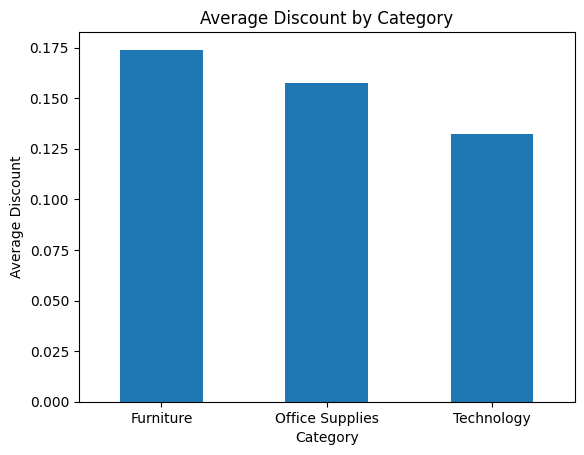

In [9]:
category_discount = (
    df.groupby("Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

category_discount.plot(kind="bar")
plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.xticks(rotation=0)
plt.show()

Observation:

The Furniture category marked the highest average discount (nearing 0,175 or 17.5%), followed closely by Office Supplies in second place (around 15.8%). Conversely, the Technology category maintained the lowest promotional deduction among the three, sitting at approximately 0.133 or 13.3%.

Insight:

The elevated discount rates within the Furniture segment indicate an aggressive price-cutting strategy, likely utilized to stimulate demand or accelerate inventory turnover. When tied to broader financial performance, this heavy promotional reliance poses a substantial risk of eroding the net profit margins of Furniture, whereas the Technology sector showcases better margin resilience due to a more controlled discount structure.

Recommendation:

Management should rigorously evaluate price elasticity and promotional effectiveness within the Furniture segment. It is highly recommended to perform a cross-correlation analysis between promotional costs and realized net profit to ensure that discounts are driving sustainable growth rather than cannibalizing margins. Furthermore, shifting from flat discounts to volume-based incentives could be explored to protect the company's bottom line.

## Profit Margin by Category

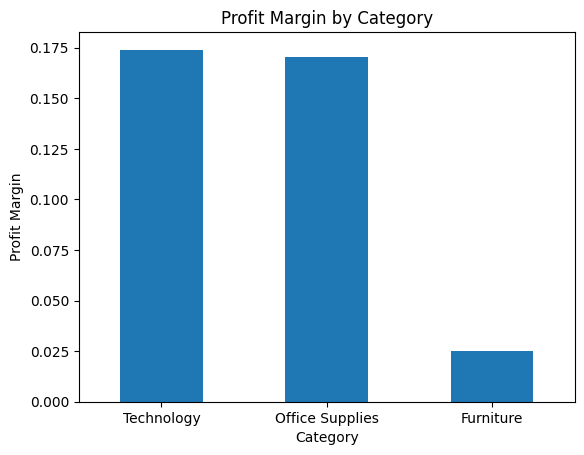

In [10]:
category_summary = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
}).round(2)

category_summary["Profit Margin"] = (
    category_summary["Profit"] / category_summary["Sales"]
).round(4)

category_summary["Profit Margin"].sort_values(ascending=False).plot(kind="bar")
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.xticks(rotation=0)
plt.show()

Observation:

The Technology category registered the highest profit margin ratio (nearing 0.175 or 17.5%), followed closely by Office Supplies in second place (around 17.0%). In stark contrast, the Furniture category lags significantly behind at the bottom, securing a very narrow profit margin of only about 0.025 or 2.5%.

Insight:

Even though Furniture was previously shown to generate substantial sales volume, its actual capacity to yield net profit is extremely weak. This strongly indicates that the profitability of the Furniture segment is heavily diluted by high operational costs or an overly aggressive discounting strategy (as evidenced by its high 17.5% average discount rate). Conversely, Technology and Office Supplies stand out as far more financially efficient product lines, successfully converting top-line revenue into net income at an optimal rate.

Recommendation:

The company must immediately restructure its strategy for the Furniture category by auditing its core pricing structure, implementing stricter discount caps, and optimizing supply chain costs to push the margin to a healthier level. For Technology and Office Supplies, management should actively scale operations and expand market share; since these categories possess high-margin efficiency, any increase in their sales volume will directly maximize the company's overall bottom-line net profit.

After analyzing category-level performance, the next step is to examine product-level performance to identify which specific products contribute the most to profit and which products generate losses.

## Product Analysis

In [11]:
product_summary = df.groupby("Product Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
}).round(2)

product_summary["Profit Margin"] = (
    product_summary["Profit"] / product_summary["Sales"]
).round(4)

product_summary = product_summary.sort_values(by="Profit")

## Top 10 Lowest Profit Products

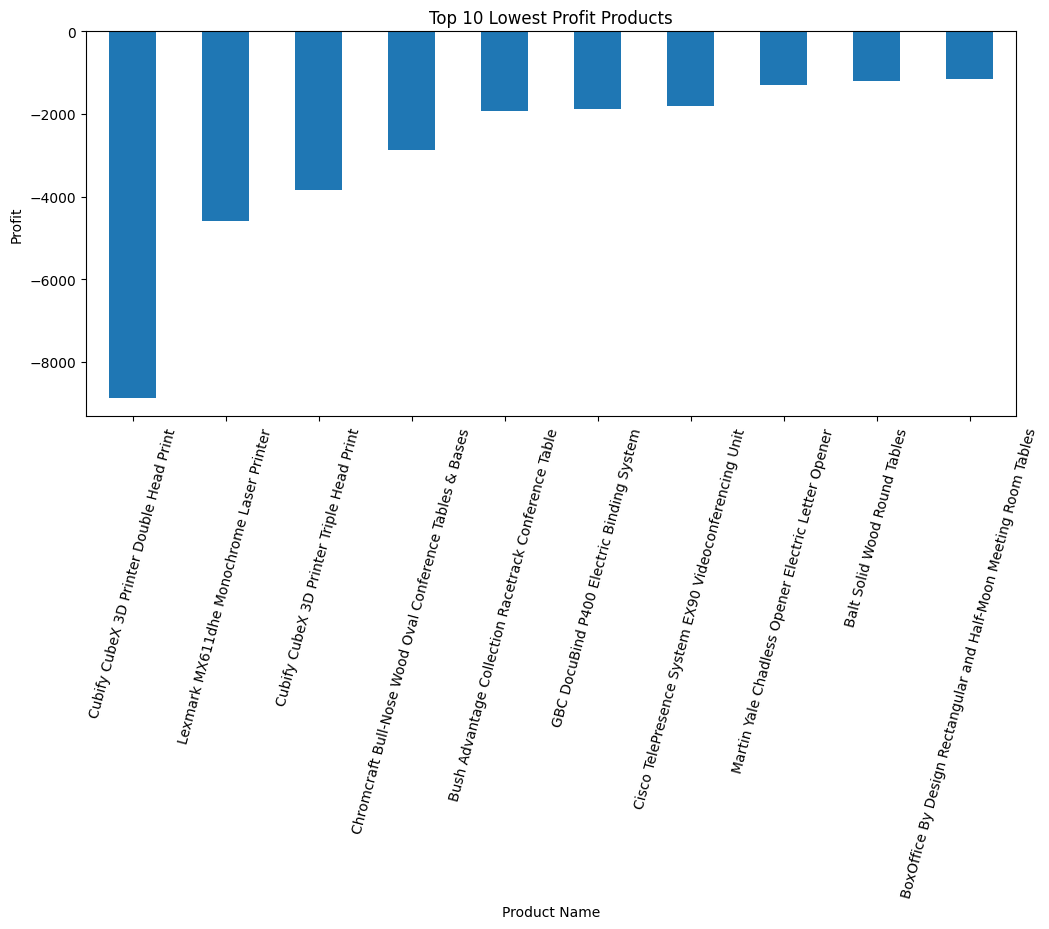

In [12]:
lowest_profit_products = product_summary.sort_values(by="Profit").head(10)

lowest_profit_products["Profit"].plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Lowest Profit Products")
plt.xlabel("Product Name")
plt.ylabel("Profit")
plt.xticks(rotation=75)
plt.show()

## Top 10 Highest Profit Products

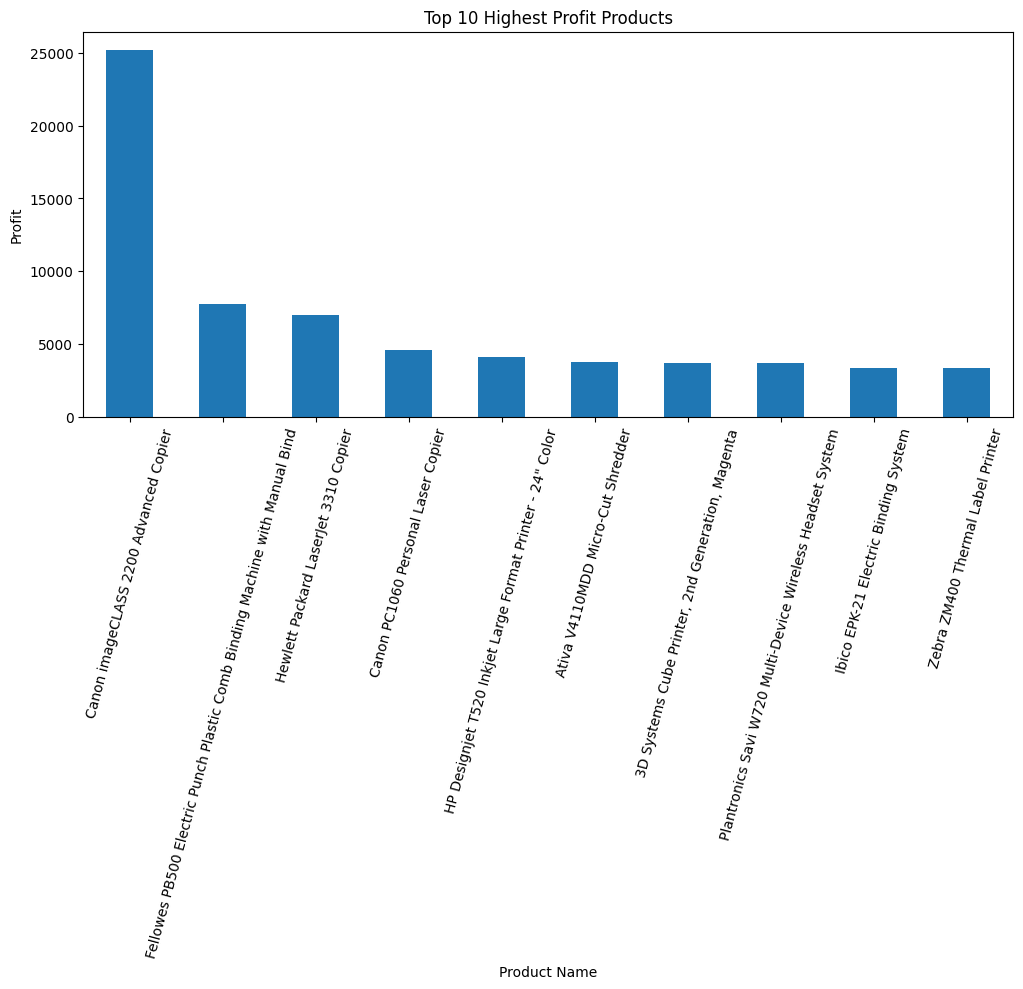

In [13]:
top_profit_products = product_summary.sort_values(by="Profit", ascending=False).head(10)

top_profit_products["Profit"].plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Highest Profit Products")
plt.xlabel("Product Name")
plt.ylabel("Profit")
plt.xticks(rotation=75)
plt.show()

Observation:

Based on the product performance data at both extremes, the Canon imageCLASS 2200 Advanced Copier is recorded as the largest profit contributor for the company, yielding a net profit that surpasses 25,000. Conversely, the Cubify CubeX 3D Printer Double Head Print stands out as the most significant loss-generating product, with a negative profit nearing -9,000. Furthermore, high-volume sales products, such as the Cisco TelePresence System EX90 Videoconferencing Unit, are also notably detected within the ranks of the top ten lowest-profit products.

Insight:

This SKU-level analysis indicates that a high sales volume or top-line value does not automatically guarantee a positive profit contribution to the company. The negative profit observed across several prominent products is strongly suspected to be correlated with overly aggressive discounting practices and sub-optimal pricing frameworks. This is evidenced by the tendency of most loss-generating items to carry elevated discount rates alongside negative profit margins, contrasting sharply with the Canon imageCLASS line, which successfully safeguards high margins through a more controlled and disciplined discount structure.

Recommendation:

The company is advised to maintain its current commercial strategy for high-performing products like the Canon imageCLASS and leverage them as anchor products for cross-selling or bundling initiatives to lift other segments. Concurrently, management must conduct a comprehensive audit of the loss-generating products—particularly the Cubify CubeX and Cisco TelePresence—by implementing more selective discount caps and re-evaluating baseline pricing structures to restore financial efficiency and prevent further erosion of overall profitability.

While understanding individual product performance reveals what drives our profit and losses, analyzing these dynamics across different geographies is essential. Therefore, the next section moves from product-specific results to a regional analysis to examine where our profitability is geographically concentrated.

## Profit by Region

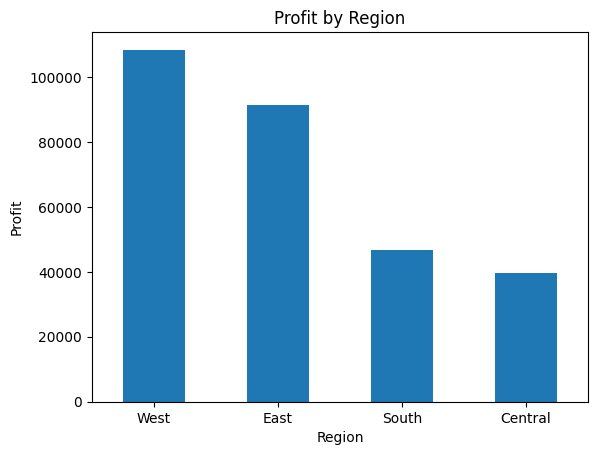

In [14]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

Observation:

The West region achieved the highest total profit (surpassing 100,000), followed closely by the East region in second place (around 90,000). In contrast, the South and Central regions generated substantially lower profits, sitting below 50,000 and 40,000 respectively. There is a noticeable profitability gap between the top two performing regions and the bottom two.

Insight:

The company's overall profitability is heavily reliant on the West and East regions, which combined generate the vast majority of the business's net income. Conversely, the lagging profits in the South and Central regions point toward potential operational inefficiencies, high logistical or promotional costs, or weak market penetration that restricts net margin optimization.

Recommendation:

The company must secure its market leadership in the West and East through ongoing customer retention programs and sustained operational excellence. Concurrently, management should conduct a comprehensive audit of the cost structures, pricing strategies, and distribution channels within the South and Central regions to pinpoint the root causes of low margins and drive financial turnaround in these underperforming areas.

Having identified the geographic distribution of our sales and profits, the final step is to examine how these metrics have evolved over time. The next section transitions into a yearly analysis to assess the long-term trend and growth trajectory of the business.

## Sales by Year

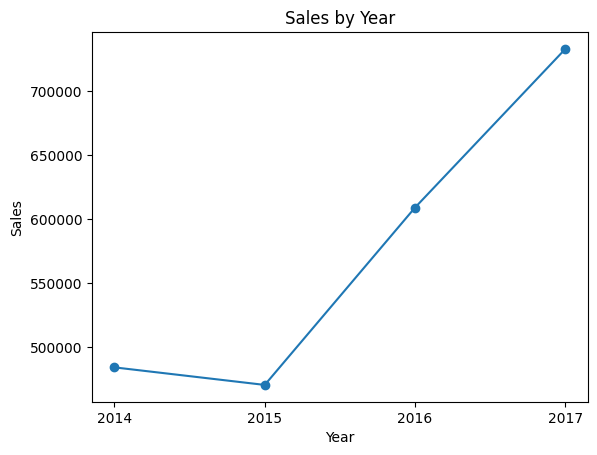

In [15]:
year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

year_sales.plot(kind="line", marker="o")
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(year_sales.index)
plt.show()

Observation:

There was a minor decline in sales volume from 2014 to 2015 (dropping from approximately 485,000 to 470,000). However, post-2015, the chart demonstrates a sharp upward trajectory, with substantial consecutive increases recorded in 2016 (surpassing 600,000) and peaking significantly in 2017 (nearing 730,000).

Insight:

Despite experiencing a minor setback or stagnation in the initial phase (2015), the company successfully achieved a highly robust business turnaround. The exponential growth pattern during the 2016–2017 period indicates strong market momentum, potentially driven by successful product penetration, broader customer acquisition, or highly effective strategic commercial shifts.

Recommendation:

Management should systematically audit the strategic initiatives executed in late 2015 and throughout 2016 to isolate the key success drivers for future replication and scaling. Concurrently, a retrospective analysis of the 2015 dip must be conducted to establish defensive risk-mitigation protocols, ensuring the business remains resilient against future market fluctuations.

## Sales by Month

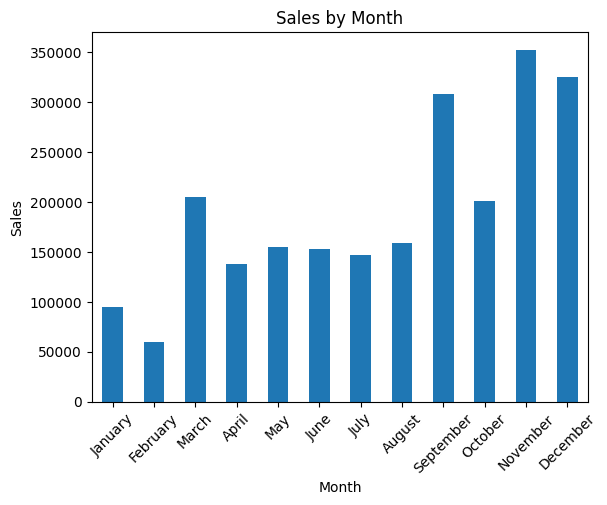

In [16]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .reindex(month_order)
)

month_sales.plot(kind="bar")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Observation:

Sales volume tends to be lower during the beginning to the middle of the year, followed by a sharp upward trend toward the end of the year, particularly in September, November, and December. November stands out as the month with the highest overall sales volume.

Insight:

The revenue distribution strongly indicates a clear seasonality pattern, where business activity accelerates significantly as the year comes to a close. This highlights the Q4 holiday period as a critical driver for the company’s annual revenue and suggests it serves as the primary momentum to hit corporate sales targets.

Recommendation:

The company should proactively prepare its inventory levels, promotional campaigns, and operational logistics well ahead of the year-end surge, ideally before November and December. Additionally, a secondary analysis should be conducted regarding the lower sales volume in the early months of the year, enabling management to design counter-seasonal strategies that stabilize revenue distribution year-round.

Having mapped the commercial growth trends from year to year, the final step to complete this report is to evaluate the fundamental relationship between sales volume and profitability at the transactional level. This concluding section transitions into a commercial correlation analysis to verify whether the expansion in sales value consistently translates into net profit growth.

## Sales VS Profit

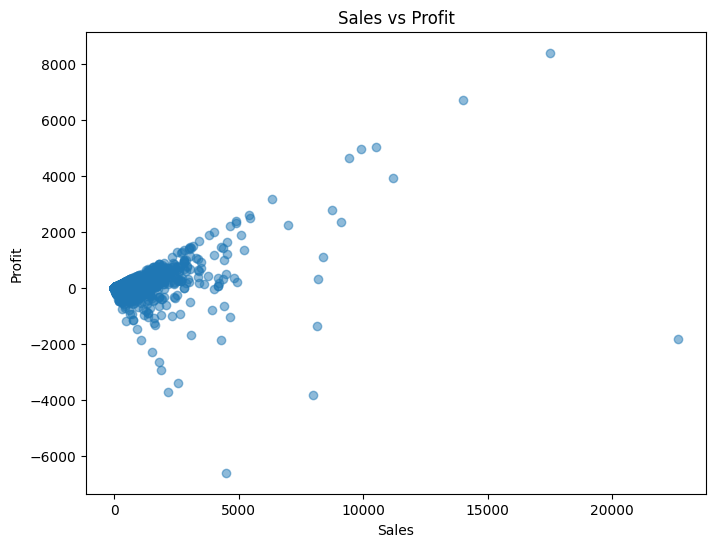

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

Observation:

The scatter plot demonstrates that the vast majority of transactions are highly concentrated within the low-value sales volume area (below 5,000), with profit margins tightly clustering around zero. While a positive linear trend is visible for several high-value transactions (sales above 10,000 driving higher profits), there are prominent and extreme outliers where high sales volumes (with one even exceeding 22,000) resulted in substantial financial losses, dipping below -2,000 and -6,000.

Insight:

The data distribution indicates that a higher top-line sales value does not inherently guarantee proportional bottom-line profitability. The presence of large-scale, loss-generating transaction outliers strongly points toward transactional anomalies, such as severe pricing errors on major contracts, undisciplined corporate discounting, or unforeseen logistical cost overruns. This indicates that increasing sales alone does not guarantee higher profitability, highlighting the importance of pricing strategy, discount management, and product margin optimization.

Recommendation:

Management is highly advised to immediately conduct a forensic audit on all high-value, loss-making outlier transactions to isolate the root causes of margin leakage. The company should implement a systemized gatekeeping mechanism for large-scale deals, introducing a tiered approval process for any high-volume accounts requesting discounts beyond standard thresholds. This measure is critical to ensure that top-line sales expansion strictly aligns with healthy net profit generation.

# Business Insights

**Key Finding 1**

The Technology category acts as the primary revenue and margin driver, while the even distribution of sales across all three segments reflects a healthy, well-diversified product portfolio.

Business Impact:

Technology should remain the company's primary growth driver through continued investment in inventory availability, while the overall balanced portfolio ensures high market stability and cushions the business against single-category risks.

**Key Finding 2**

The Furniture segment relies on an aggressive price-cutting strategy, resulting in the highest average discount rate (17.5%) across all categories.

Business Impact:

This heavy promotional reliance poses a substantial risk of eroding Furniture's net profit margins, highlighting the need to shift toward a more controlled discount structure like the one successfully utilized in the Technology sector.

**Key Finding 3**

Despite generating substantial sales volume, Furniture's actual capacity to yield net profit is extremely weak, resulting in a narrow 2.5% profit margin compared to the high-efficiency conversions seen in Technology and Office Supplies.

Business Impact:

Top-line sales expansion does not automatically translate to bottom-line success; immediate pricing restructuring, strict discount caps, and operational cost audits are required to stop Furniture's high revenue from being heavily diluted.

**Key Finding 4**

The company's overall net income is heavily concentrated in the West and East regions, leaving the South and Central regions lagging significantly behind with sub-optimal profits.

Business Impact:

Resource allocation and market maintenance should be prioritized to secure momentum in the West and East, while targeted investigations must be launched to address suspected logistical inefficiencies or weak market penetration in the South and Central territories.

**Key Finding 5**

Following a minor commercial setback in 2015, the company successfully achieved a robust business turnaround, accelerating into an exponential growth trajectory during the 2016–2017 period.

Business Impact:

The strategic commercial shifts and customer acquisition models executed during this growth phase are highly effective and should be systematically audited to serve as a blueprint for sustaining long-term market momentum.

# Recommendations

**Priority 1**

**Audit Furniture pricing and restrict discount policies.**

The company should prioritize reviewing its strategy for the Furniture category by auditing its core pricing structure and implementing stricter discount caps. Management should rigorously evaluate price elasticity and transition from flat discounts to volume-based incentives. It is highly recommended to perform a cross-correlation analysis between promotional costs and realized net profit to ensure that future marketing efforts drive sustainable growth rather than cannibalizing the company's bottom line.

**Priority 2**

**Optimize cost structures and pricing in the South and Central regions.**

Management should conduct a comprehensive audit of the cost structures, pricing strategies, and distribution channels within the South and Central regions to pinpoint the root causes of low margins. Pinpointing these geographic inefficiencies will allow the company to drive a financial turnaround in these underperforming areas. Concurrently, the business must secure its market leadership in the West and East through ongoing customer retention programs and sustained operational excellence.

**Priority 3**

**Secure Technology inventory and maintain high service quality.**

The company should prioritize securing inventory levels and maintaining high service quality within the Technology segment to safeguard its market leadership and sustain customer loyalty. Because this category possesses high-margin efficiency, maintaining its performance momentum is critical. Any smooth scaling of operations in this sector will directly maximize the company's overall bottom-line net profit.

**Priority 4**

**Drive cross-selling and scale operations for margin-efficient categories.**

Management should actively scale operations and expand market share for both Technology and Office Supplies due to their high-margin efficiency. The company should explore targeted cross-selling initiatives or tailored marketing campaigns that leverage these high-performing products to help boost Furniture and Office Supplies sales. This strategy will capitalize on their high market potential with a relatively small operational push.

**Priority 5**

**Analyze past growth drivers and establish defensive risk-mitigation protocols.**

Management should systematically audit the strategic initiatives executed during the 2016–2017 growth phase to isolate the key success drivers for future replication and scaling. Concurrently, a retrospective analysis of the 2015 dip must be conducted to establish defensive risk-mitigation protocols. This will ensure the business remains resilient and well-prepared against future market fluctuations or seasonal shifts.

# Executive Summary

Based on the commercial performance analysis, the company's sales showed a positive growth trend during the 2016–2017 period after experiencing a slight decline in 2015. Sales remained relatively well distributed across the three product categories, with Technology contributing the highest share of total revenue, followed by Furniture and Office Supplies. This balanced distribution suggests that the company maintains a diversified revenue structure rather than relying heavily on a single product category.

Despite the positive sales performance, profitability varied considerably across regions and product categories. The West and East regions generated the highest profits, while the South and Central regions consistently recorded lower profitability. These findings indicate that further investigation is needed to identify the business factors associated with the weaker financial performance in those regions. At the category level, Furniture recorded the highest average discount (17.5%) and the lowest profit margin (2.5%). Although the current analysis cannot establish a causal relationship, the higher discount level may have contributed to the lower profitability observed in this category. In contrast, the Technology and Office Supplies categories achieved stronger profit margins while maintaining relatively lower average discount rates.

Based on these findings, the company should prioritize further analysis of the Furniture category and the South and Central regions to better understand the factors associated with their lower profitability. Evaluating pricing strategies, discount policies, and regional business performance may help identify opportunities for improvement. At the same time, the company is encouraged to maintain the strong performance of the Technology category and the West and East regions while exploring cross-selling opportunities within high-performing categories to support sustainable profit growth.

# Conclusion

This project successfully identified several business opportunities through exploratory data analysis.

Key findings include:

*   Technology drives the highest sales and maintains the strongest profit margin, closely followed by Office Supplies.
*   West Region serves as the primary profit contributor, showcasing a distinct profitability gap over the South and Central regions.
*   Furniture requires an immediate pricing and promotional evaluation due to its high average discount eroding net margins.
*   Several high-sales products, including Cubify CubeX and Cisco TelePresence, generate substantial losses instead of positive returns.
*   Yearly sales exhibit a powerful commercial turnaround, accelerating into an exponential growth trajectory during 2016–2017.
*   High-value transactional outliers indicate that expanding top-line sales without strict margin gatekeeping poses a direct threat to profitability.

The insights generated from this analysis can support future pricing structures, discount policies, regional cost optimization, and promotional strategies. These findings demonstrate how exploratory data analysis can support data-driven decision-making and provide practical recommendations for improving business performance.